In [1]:

import numpy as np, pandas as pd, datashader, yaml
from datashader import transfer_functions as tf
from datashader.colors import inferno, viridis
from numba import jit
from math import sin, cos, sqrt, fabs
from colorcet import palette
palette["viridis"]=viridis
palette["inferno"]=inferno

@jit(nopython = True)
def Clifford( x, y, a, b, c, d, *o ):
    return sin(a*y) + c*cos(a*x), sin(b*x) + d*cos(b*y)

n=100000

@jit(nopython=True)
def trajectoryCoordinates( function, x0, y0, a, b=0, c=0, d=0, e=0, f=0, n=n ):
    x, y = np.zeros(n), np.zeros(n)
    x[0], y[0] = x0, y0 
    for i in range(n-1):
        x[i+1], y[i+1] = function(x[i], y[i], a, b, c, d, e, f)
    return x, y

def trajectory( function, x0, y0, a, b=0, c=0, d=0, e=0, f=0, n=n ):
    x, y = trajectoryCoordinates( function, x0, y0, a, b, c, d, e, f, n )
    return pd.DataFrame( dict(x=x, y=y) )

def plotOne( function, parameters, n=n, cmap=viridis):
    df = trajectory(function, *parameters, n=n)
    canvas = datashader.Canvas(plot_width=100, plot_height=100)
    # aggregate coordinates into a discrete 2D grid, counting each time a point fell into that grid cell
    aggregated = canvas.points(df, 'x', 'y')
    image = tf.shade(aggregated, cmap = cmap, name= str(parameters) )
    return image

attractorsFile = r'C:\Users\rick\Documents\GitHub\tesla-cat.github.io\src\doge\Attractors\strange_attractors.yml'
attractors = yaml.load(open(attractorsFile,"r"), Loader=yaml.FullLoader)
def plot(function, parametersList=None, **kwargs):
    if parametersList is None:
        parametersList = [ params[1:] for params in attractors if params[0] == function.__name__ ]
    return tf.Images(*[ plotOne(function, params[1:], cmap=palette[params[0]][::-1], **kwargs) for params in parametersList]).cols(4)

"[0, 0, -1.3, -1.3, -1.8, -1.9]","[0, 0, -1.4, 1.6, 1.0, 0.7]","[0, 0, 1.7, 1.7, 0.6, 1.2]","[0, 0, 1.7, 0.7, 1.4, 2.0]"
"[0, 0, -1.7, 1.8, -1.9, -0.4]","[0, 0, 1.1, -1.32, -1.03, 1.54]","[0, 0, 0.77, 1.99, -1.31, -1.45]","[0, 0, -1.9, -1.9, -1.9, -1.0]"
"[0, 0, 0.75, 1.34, -1.93, 1.0]","[0, 0, -1.32, -1.65, 0.74, 1.81]","[0, 0, -1.6, 1.6, 0.7, -1.0]","[0, 0, -1.7, 1.5, -0.5, 0.7]"

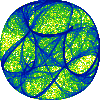
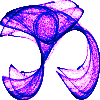
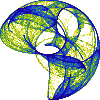
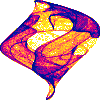
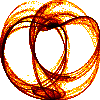
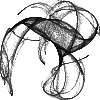
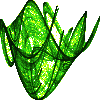
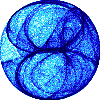
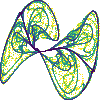
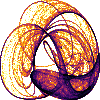
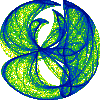
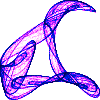

In [2]:
plot(Clifford)